# Topological graph embedding of single-cell hematopoiesis

This notebook applies `TopologicalSplineGraph` to the Paul et al. (2015) mouse bone-marrow MARS-seq experiment. The expression matrix is used for fitting; author-provided cell-type annotations are used only for coloring and post-fit diagnostics.

The data are downloaded from Scanpy's public `paul15.h5` distribution and cached outside the repository.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from sklearn.decomposition import PCA

working_dir = Path.cwd().resolve()
notebooks_dir = working_dir / 'notebooks' if (working_dir / 'notebooks' / '__init__.py').exists() else working_dir
project_root = notebooks_dir.parent
if not (project_root / 'topological_graph_embedding').exists():
    raise RuntimeError('Start Jupyter from the repository root or its notebooks/ directory')
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(notebooks_dir))

from topological_spline_graph import TopologicalSplineGraph
from spline_visualization import (
    plot_embedding_row,
)

from paul_single_cell import (
    BROAD_LINEAGE, LINEAGE_ORDER, LINEAGE_PALETTE, TYPE_ORDER,
    _plot_splines_in_pca, load_paul15,
    one_nn_accuracy_2d, plot_expression_panels,
    plot_graph_coordinate_embedding, preprocess_paul15,
    scatter_categories,
)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## Load and preprocess the single-cell data

The preprocessing follows the sister repo's notebook: restrict to informative genes, remove cells with fewer than 300 detected genes, remove genes seen in fewer than five cells, library-size normalize, log-transform, retain the 750 most variable genes, and z-score with clipping. No labels enter these steps.

In [2]:
raw = load_paul15()
processed = preprocess_paul15(raw)
X = processed["X"]
cell_types = processed["cell_types"]
print(f"Source: {raw['data_path']}")
print(f"Loaded {raw['counts'].shape[0]:,} cells × {raw['counts'].shape[1]:,} genes")
print(f"After QC: {X.shape[0]:,} cells × {X.shape[1]:,} highly variable genes")
print(f"Median library size: {np.median(processed['library_size']):.0f}")
print(f"Median detected genes: {np.median(processed['detected_genes']):.0f}")
print("Cell types:", ", ".join(f"{name}={np.sum(cell_types == name)}" for name in TYPE_ORDER))

Source: /Users/f.costa/.cache/topologicalgraphembedding/paul15.h5
Loaded 2,730 cells × 8,716 genes
After QC: 2,494 cells × 750 highly variable genes
Median library size: 1820
Median detected genes: 793
Cell types: Ery=1065, MEP=64, Mk=61, GMP=183, DC=23, Baso=347, Mo=555, Neu=177, Eos=6, Lymph=13


## Fit the topological graph and compute graph coordinates

The model fits a compact spline skeleton in the 750-dimensional expression space. Each cell is projected to its nearest spline, producing an intrinsic coordinate `(highway_id, t)` and a residual distance from the fitted graph. All `TopologicalSplineGraph` parameters are kept here so the fit is directly inspectable and adjustable.

In [3]:
model = TopologicalSplineGraph(
    n_centroids=48,
    persistence_threshold=None,
    spline_smoothing=0.02,
    max_cycles=4,
    random_state=42,
    standardize=True,
    merge_junction_distance=None,
    prune_short_branches=True,
    prune_branch_factor=0.5,
    persistence_max_points=60,
    spline_samples_per_node=12,
    linear_structure_tolerance=0.12,
)
result = model.fit_transform(X)
embedding = np.column_stack([result["t"], result["highway_id"]])
pca = PCA(n_components=2, random_state=42).fit(X)
print(f"Centroids: {len(model.centroids_)}")
print(f"Spline highways: {len(model.splines_)}")
print(f"Cycles: {model.cycle_count_}")
print(f"Junctions: {len(model.junction_nodes_)}; endpoints: {len(model.endpoint_nodes_)}")
print(f"Median graph residual: {np.median(result['residual_norm']):.3f}")

Centroids: 48
Spline highways: 34
Cycles: 0
Junctions: 1; endpoints: 34
Median graph residual: 26.417


## Cell-type relationships

The shared four-view visualization is used here as well: PCA with the fitted spline graph, intrinsic graph coordinates, metro-map lines, and metro-map points. The 1-NN value is a simple separation diagnostic, not a training objective.

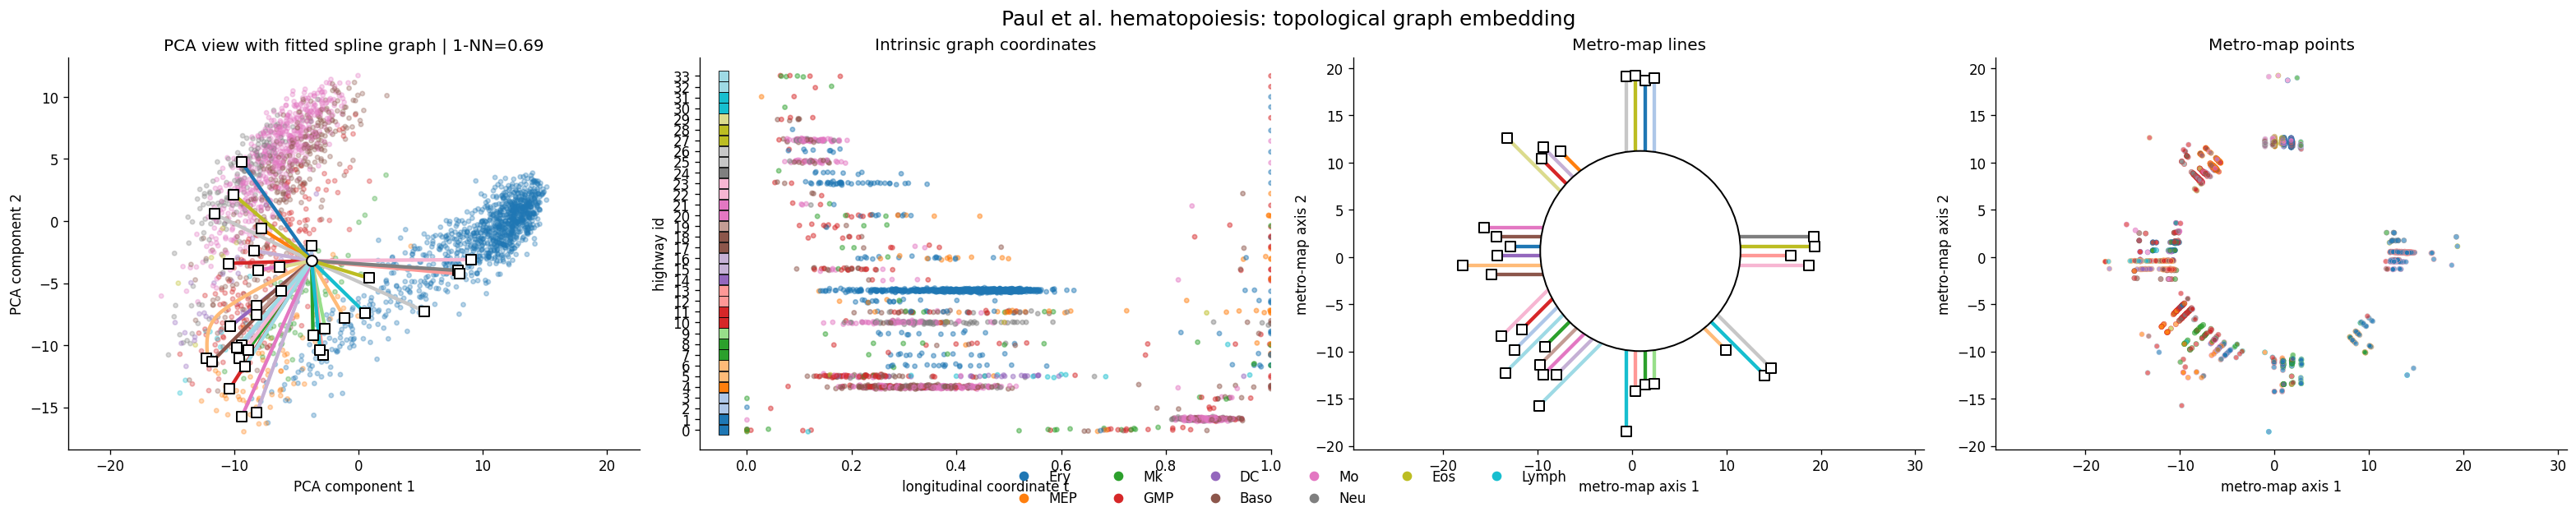

In [4]:
pca_coordinates = pca.transform(X)
pca_accuracy = one_nn_accuracy_2d(pca_coordinates, cell_types)
cell_type_codes = np.asarray([TYPE_ORDER.index(label) for label in cell_types])
fig, axes = plt.subplots(1, 4, figsize=(26, 5), constrained_layout=True)
plot_embedding_row(
    axes, X, cell_type_codes, model, result,
    projected_title=f"PCA view with fitted spline graph | 1-NN={pca_accuracy:.2f}",
    graph_title="Intrinsic graph coordinates",
    metro_lines_title="Metro-map lines",
    metro_points_title="Metro-map points",
    reducer=pca,
    jitter_seed=42,
    show_metro_nodes=False,
)
legend_handles = [
    Line2D([0], [0], marker="o", linestyle="", color=plt.get_cmap("tab10")(index), label=label)
    for index, label in enumerate(TYPE_ORDER)
]
fig.legend(legend_handles, TYPE_ORDER, loc="lower center", ncol=6, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Paul et al. hematopoiesis: topological graph embedding", fontsize=15)
plt.show()

## Broad lineages and marker genes

These panels provide a biological sanity check without changing the unsupervised fit.

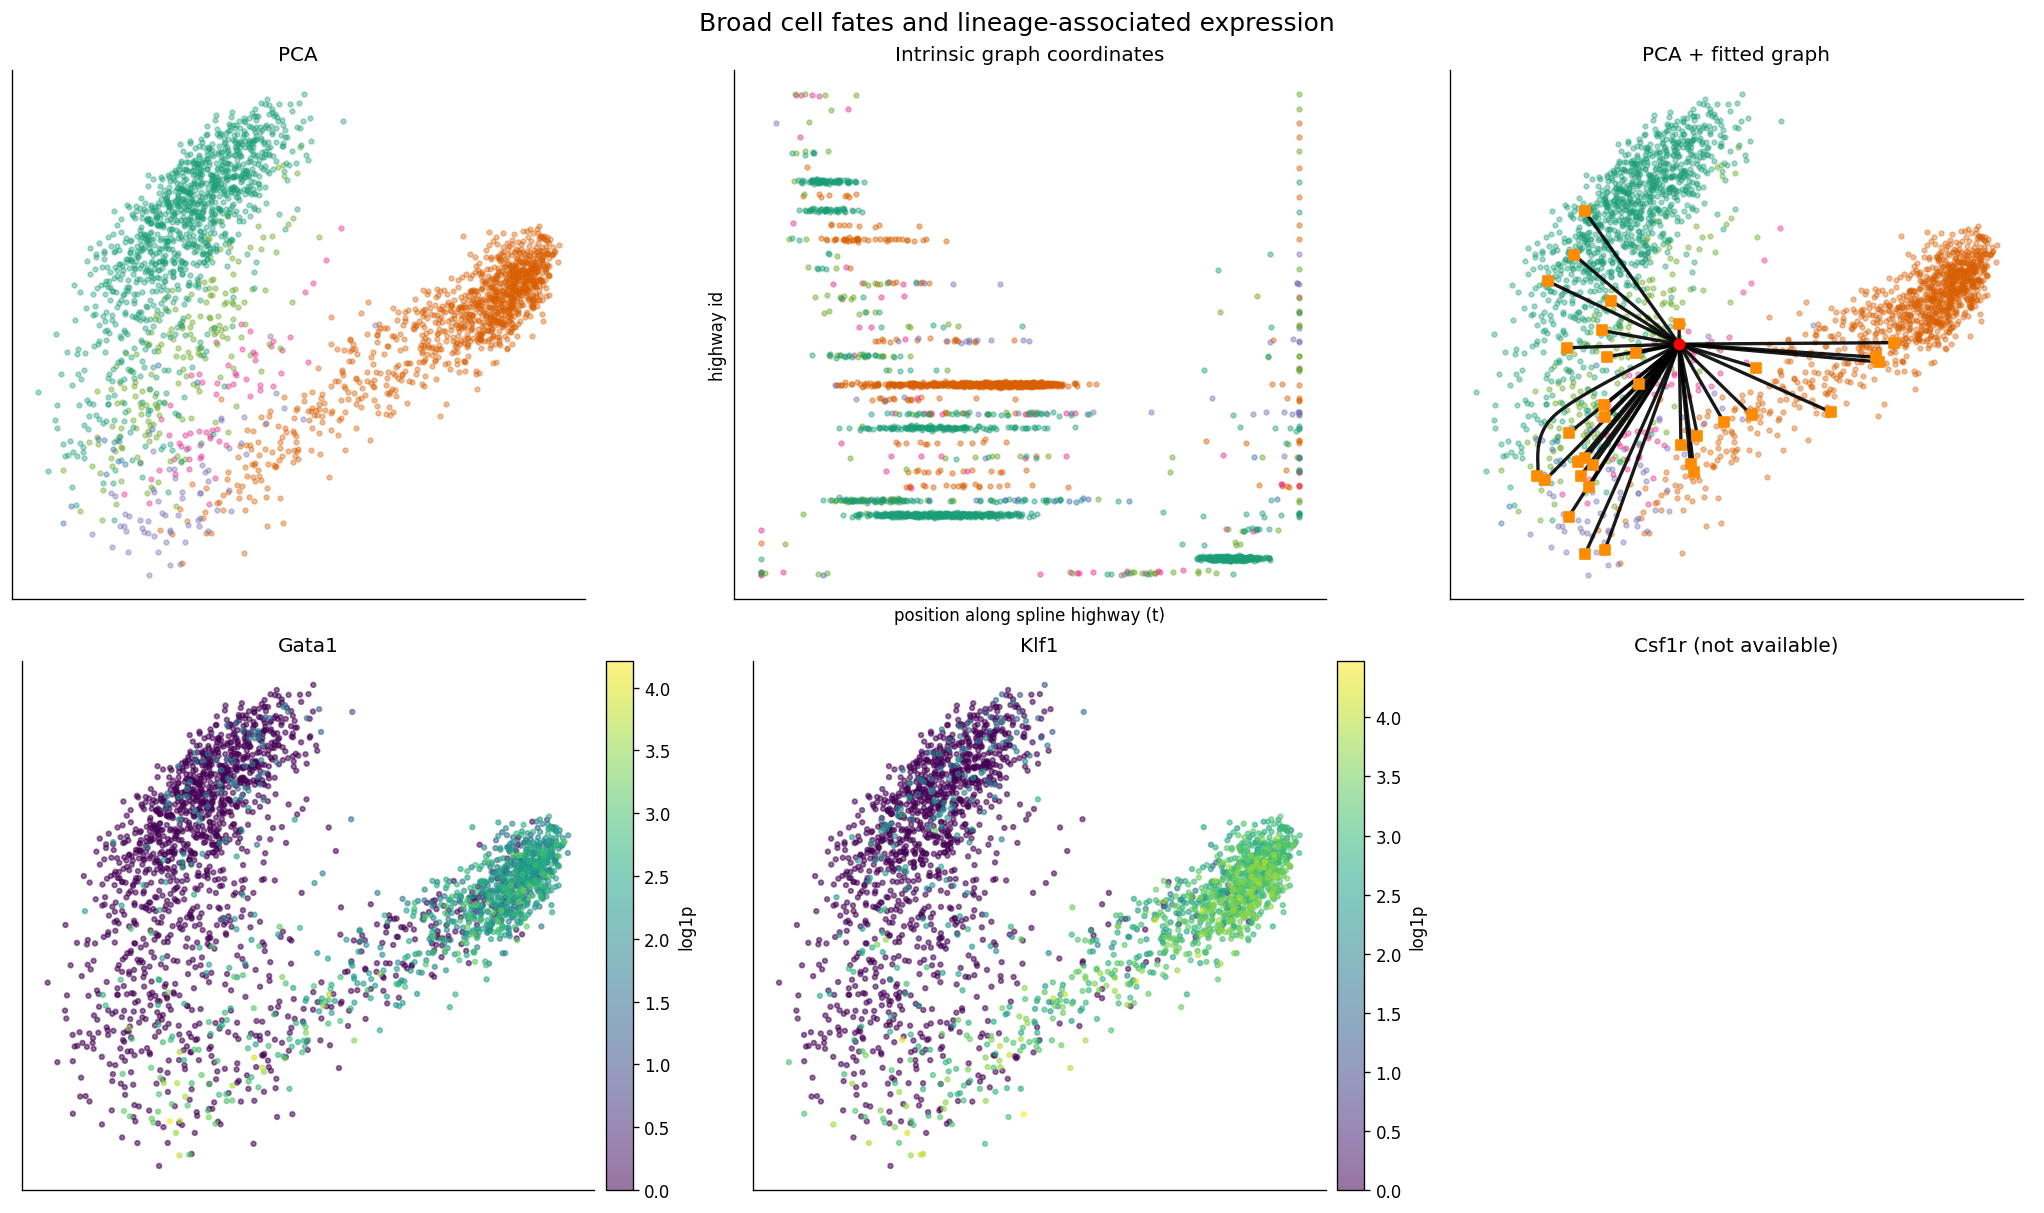

Available marker panels: ['Gata1', 'Klf1']


In [5]:
lineage_labels = np.asarray([BROAD_LINEAGE[cell_type] for cell_type in cell_types])
fig, axes = plt.subplots(2, 3, figsize=(17, 10), constrained_layout=True)
for ax, title in zip(axes[0], ["PCA", "Intrinsic graph coordinates", "PCA + fitted graph"]):
    if title == "Intrinsic graph coordinates":
        plot_graph_coordinate_embedding(ax, result, lineage_labels, LINEAGE_ORDER, LINEAGE_PALETTE)
    else:
        scatter_categories(ax, pca_coordinates, lineage_labels, LINEAGE_ORDER, LINEAGE_PALETTE)
        if title.endswith("fitted graph"): _plot_splines_in_pca(ax, model, pca)
        ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
available_markers = plot_expression_panels(
    fig, axes[1], pca_coordinates, processed["X_log"],
    processed["selected_gene_names"], ["Gata1", "Klf1", "Csf1r", "Mpo", "Elane", "Gata2"],
)
fig.suptitle("Broad cell fates and lineage-associated expression", fontsize=15)
plt.show()
print("Available marker panels:", available_markers)

## Interpretation

The fitted splines summarize relationships among expression states; they are not a formal lineage-inference method. This static snapshot contains no RNA velocity, time labels, perturbations, or fate probabilities.